In [1]:
!pip install -q torch-geometric grad-cam

import os, pandas as pd

DATA_ROOT = "/kaggle/input/datasets/ashery/chexpert"
train_csv = pd.read_csv(f"{DATA_ROOT}/train.csv")
valid_csv = pd.read_csv(f"{DATA_ROOT}/valid.csv")

print(train_csv.columns.tolist())
print(train_csv['Path'].iloc[0])

# Check actual folder structure
print(os.listdir(DATA_ROOT))
sample_path = train_csv['Path'].iloc[0]
# Try a few prefix guesses
for prefix in ["", "CheXpert-v1.0-small/", "../"]:
    full = os.path.join(DATA_ROOT, prefix, sample_path.split("CheXpert-v1.0-small/")[-1] if "CheXpert-v1.0-small/" in sample_path else sample_path)
    print(prefix, "->", full, os.path.exists(full))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 71.2 MB/s eta 0:00:00:00:010:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 59.5 MB/s eta 0:00:00
['Path', 'Sex', 'Age', 'Frontal/Lateral', 'AP/PA', 'No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis', 'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture', 'Support Devices']
CheXpert-v1.0-small/train/patient00001/study1/view1_frontal.jpg
['valid.csv', 'valid', 'train.csv', 'train']
 -> /kaggle/input/datasets/ashery/chexpert/train/patient00001/study1/view1_frontal.jpg True
CheXpert-v1.0-small/ -> /kaggle/input/datasets/ashery/chexpert/CheXpert-v1.0-small/train/patient00001/study1/view1_frontal.jpg False
../ -

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
import numpy as np
import pandas as pd
import os
from sklearn.metrics import f1_score, roc_auc_score
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

DATA_ROOT = "/kaggle/input/datasets/ashery/chexpert"
DISEASES = ["Cardiomegaly", "Edema", "Pleural Effusion",
            "Consolidation", "Atelectasis", "Pneumothorax", "Lung Opacity"]

def resolve_path(p):
    return os.path.join(DATA_ROOT, p.split("CheXpert-v1.0-small/")[-1])

cuda


In [3]:
train_csv = pd.read_csv(f"{DATA_ROOT}/train.csv")
valid_csv = pd.read_csv(f"{DATA_ROOT}/valid.csv")

def preprocess(df):
    df = df.copy()
    df["full_path"] = df["Path"].apply(resolve_path)
    for d in DISEASES:
        df[d] = df[d].fillna(0)
        df[d] = df[d].replace(-1, 0)  # U-Zeros
    return df

train_df = preprocess(train_csv)
valid_df = preprocess(valid_csv)

print("Train:", len(train_df), "Valid:", len(valid_df))
print(train_df[DISEASES].sum())  # sanity check positive counts per disease

Train: 223414 Valid: 234
Cardiomegaly         27000.0
Edema                52246.0
Pleural Effusion     86187.0
Consolidation        14783.0
Atelectasis          33376.0
Pneumothorax         19448.0
Lung Opacity        105581.0
dtype: float64


In [4]:
class CheXpertDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["full_path"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        labels = torch.tensor(row[DISEASES].values.astype("float32"))
        return img, labels

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = CheXpertDataset(train_df, transform=transform)
valid_dataset = CheXpertDataset(valid_df, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
valid_loader = DataLoader(valid_dataset, batch_size=16, shuffle=False, num_workers=2)

print(len(train_dataset), len(valid_dataset))

223414 234


In [5]:
model = models.densenet121(weights="IMAGENET1K_V1")
model.classifier = nn.Linear(model.classifier.in_features, len(DISEASES))
model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.BCEWithLogitsLoss()

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 178MB/s]


In [10]:
model.load_state_dict(torch.load("best_chexpert_model.pth"))

EPOCHS = 15
START_EPOCH = 1  # already completed epoch 1 (index 0)
PATIENCE = 3
best_val_loss = 0.4414  # from your completed epoch 1
patience_counter = 0

train_losses, val_losses = [], []

for epoch in range(START_EPOCH, EPOCHS):
    model.train()
    running_loss = 0.0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
    train_loss = running_loss / len(train_dataset)
    train_losses.append(train_loss)

    model.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for imgs, labels in valid_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item() * imgs.size(0)
    val_loss = val_running_loss / len(valid_dataset)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_chexpert_model.pth")
        print("  -> Saved new best model")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print("Early stopping triggered.")
            break

torch.save(model.state_dict(), "chexpert_densenet_final.pth")

Epoch 2/15 - Train Loss: 0.3646 - Val Loss: 0.4241
  -> Saved new best model
Epoch 3/15 - Train Loss: 0.3567 - Val Loss: 0.4193
  -> Saved new best model
Epoch 4/15 - Train Loss: 0.3509 - Val Loss: 0.4127
  -> Saved new best model


KeyboardInterrupt: 

In [12]:
import os
print(os.path.exists("best_chexpert_model.pth"))

True


In [13]:
model.load_state_dict(torch.load("best_chexpert_model.pth"))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in valid_loader:
        imgs = imgs.to(device)
        outputs = torch.sigmoid(model(imgs)).cpu().numpy()
        all_preds.append(outputs)
        all_labels.append(labels.numpy())

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

cnn_f1 = {}
cnn_auc = {}
for i, d in enumerate(DISEASES):
    preds_binary = (all_preds[:, i] > 0.5).astype(int)
    cnn_f1[d] = f1_score(all_labels[:, i], preds_binary, zero_division=0)
    try:
        cnn_auc[d] = roc_auc_score(all_labels[:, i], all_preds[:, i])
    except ValueError:
        cnn_auc[d] = float("nan")

print("CNN F1:", cnn_f1)
print("CNN ROC-AUC:", cnn_auc)

CNN F1: {'Cardiomegaly': 0.21052631578947367, 'Edema': 0.5294117647058824, 'Pleural Effusion': 0.752, 'Consolidation': 0.0, 'Atelectasis': 0.0, 'Pneumothorax': 0.5454545454545454, 'Lung Opacity': 0.7793427230046949}
CNN ROC-AUC: {'Cardiomegaly': np.float64(0.8044826364280652), 'Edema': np.float64(0.9223985890652557), 'Pleural Effusion': np.float64(0.9327017606577889), 'Consolidation': np.float64(0.9187396351575456), 'Atelectasis': np.float64(0.7413149350649351), 'Pneumothorax': np.float64(0.9203539823008849), 'Lung Opacity': np.float64(0.9195326278659611)}


In [14]:
for i, d in enumerate(DISEASES):
    print(d, "max pred:", all_preds[:, i].max(), "mean pred:", all_preds[:, i].mean(), "positive rate:", all_labels[:, i].mean())

Cardiomegaly max pred: 0.7361574 mean pred: 0.0867754 positive rate: 0.2905983
Edema max pred: 0.89342415 mean pred: 0.18323506 positive rate: 0.1923077
Pleural Effusion max pred: 0.97723216 mean pred: 0.2935851 positive rate: 0.2863248
Consolidation max pred: 0.31096435 mean pred: 0.059418652 positive rate: 0.14102565
Atelectasis max pred: 0.4404498 mean pred: 0.13875775 positive rate: 0.34188035
Pneumothorax max pred: 0.86565053 mean pred: 0.053915855 positive rate: 0.034188036
Lung Opacity max pred: 0.81400806 mean pred: 0.384198 positive rate: 0.53846157


In [15]:
from sklearn.metrics import precision_recall_curve

cnn_f1 = {}
cnn_auc = {}
cnn_threshold = {}

for i, d in enumerate(DISEASES):
    precisions, recalls, thresholds = precision_recall_curve(all_labels[:, i], all_preds[:, i])
    f1s = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    best_idx = np.argmax(f1s[:-1])  # last point has no threshold
    best_threshold = thresholds[best_idx]
    cnn_threshold[d] = best_threshold

    preds_binary = (all_preds[:, i] > best_threshold).astype(int)
    cnn_f1[d] = f1_score(all_labels[:, i], preds_binary, zero_division=0)
    try:
        cnn_auc[d] = roc_auc_score(all_labels[:, i], all_preds[:, i])
    except ValueError:
        cnn_auc[d] = float("nan")

print("CNN F1 (best threshold):", cnn_f1)
print("CNN ROC-AUC:", cnn_auc)
print("Thresholds used:", cnn_threshold)

CNN F1 (best threshold): {'Cardiomegaly': 0.6164383561643836, 'Edema': 0.7472527472527473, 'Pleural Effusion': 0.7703703703703704, 'Consolidation': 0.6265060240963856, 'Atelectasis': 0.6291079812206573, 'Pneumothorax': 0.4, 'Lung Opacity': 0.8518518518518519}
CNN ROC-AUC: {'Cardiomegaly': np.float64(0.8044826364280652), 'Edema': np.float64(0.9223985890652557), 'Pleural Effusion': np.float64(0.9327017606577889), 'Consolidation': np.float64(0.9187396351575456), 'Atelectasis': np.float64(0.7413149350649351), 'Pneumothorax': np.float64(0.9203539823008849), 'Lung Opacity': np.float64(0.9195326278659611)}
Thresholds used: {'Cardiomegaly': np.float32(0.06156319), 'Edema': np.float32(0.33532634), 'Pleural Effusion': np.float32(0.41424632), 'Consolidation': np.float32(0.09867524), 'Atelectasis': np.float32(0.10339197), 'Pneumothorax': np.float32(0.53551126), 'Lung Opacity': np.float32(0.2870361)}


100%|██████████| 64/64 [00:03<00:00, 17.40it/s]


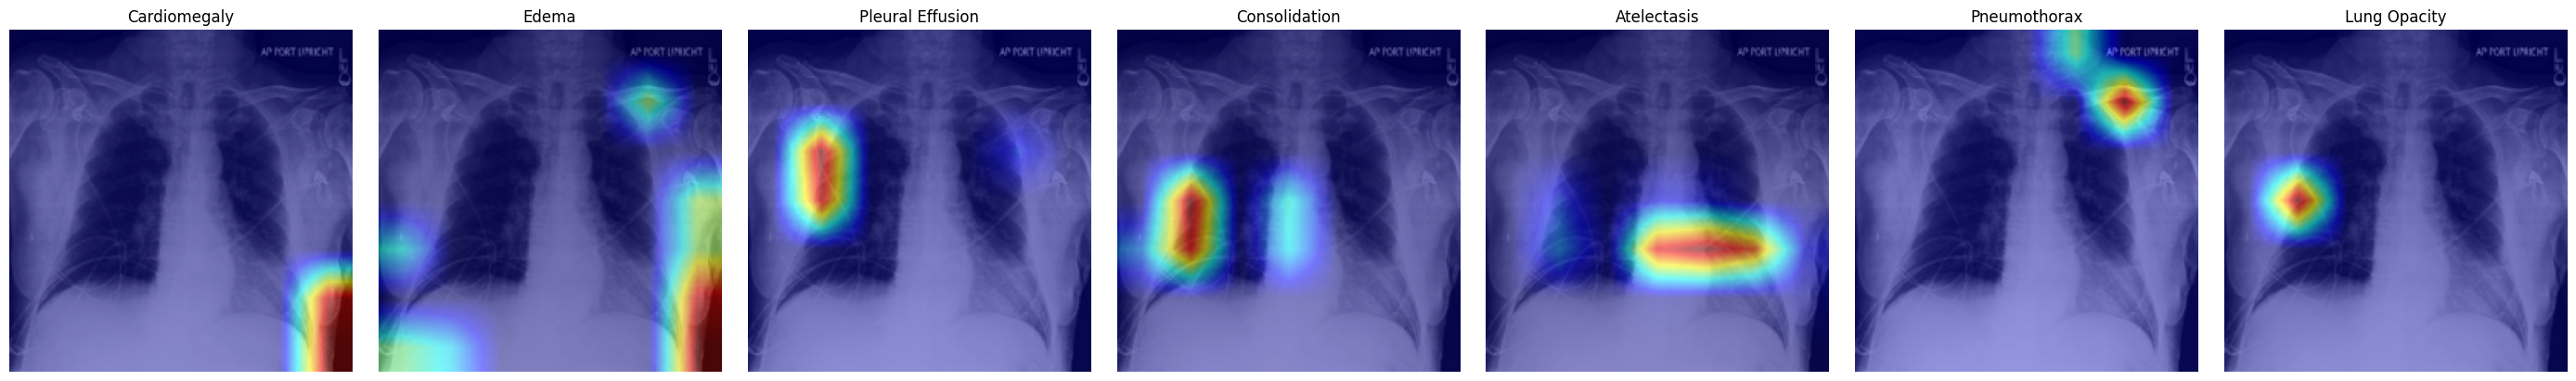

In [16]:
from pytorch_grad_cam import ScoreCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import cv2

target_layers = [model.features.denseblock4]
cam = ScoreCAM(model=model, target_layers=target_layers)

sample_img, sample_label = valid_dataset[0]
input_tensor = sample_img.unsqueeze(0).to(device)

# unnormalize for display
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
rgb_img = sample_img.permute(1,2,0).numpy() * std + mean
rgb_img = np.clip(rgb_img, 0, 1)

fig, axes = plt.subplots(1, len(DISEASES), figsize=(4*len(DISEASES), 4))
for i, d in enumerate(DISEASES):
    targets = [ClassifierOutputTarget(i)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
    axes[i].imshow(visualization)
    axes[i].set_title(d)
    axes[i].axis("off")
plt.tight_layout()
plt.savefig("scorecam_grid.png")
plt.show()

In [17]:
feature_model = models.densenet121(weights=None)
feature_model.classifier = nn.Identity()
feature_model.load_state_dict(
    {k: v for k, v in torch.load("best_chexpert_model.pth").items() if "classifier" not in k},
    strict=False
)
feature_model = feature_model.to(device)
feature_model.eval()

def extract_embeddings(loader, dataset):
    embeddings, labels_all = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            emb = feature_model(imgs)
            embeddings.append(emb.cpu())
            labels_all.append(labels)
    return torch.cat(embeddings), torch.cat(labels_all)

train_emb, train_lbl = extract_embeddings(train_loader, train_dataset)
valid_emb, valid_lbl = extract_embeddings(valid_loader, valid_dataset)

torch.save({"emb": train_emb, "lbl": train_lbl}, "train_embeddings.pt")
torch.save({"emb": valid_emb, "lbl": valid_lbl}, "valid_embeddings.pt")
print(train_emb.shape, valid_emb.shape)

torch.Size([223414, 1024]) torch.Size([234, 1024])


In [18]:
NUM_DISEASES = len(DISEASES)
NODE_DIM = 128

class DiseaseNodeProjector(nn.Module):
    def __init__(self, in_dim=1024, out_dim=NODE_DIM, num_diseases=NUM_DISEASES):
        super().__init__()
        self.heads = nn.ModuleList([
            nn.Sequential(nn.Linear(in_dim, out_dim), nn.ReLU())
            for _ in range(num_diseases)
        ])
    def forward(self, x):
        return torch.stack([head(x) for head in self.heads], dim=1)  # [B, num_diseases, out_dim]

projector = DiseaseNodeProjector().to(device)

# Build co-occurrence weighted edges from training labels
co = (train_lbl.T @ train_lbl).float()
co.fill_diagonal_(0)
co_norm = co / co.max()

edge_index_list, edge_weight_list = [], []
for i in range(NUM_DISEASES):
    for j in range(NUM_DISEASES):
        if i != j and co_norm[i, j] > 0:
            edge_index_list.append([i, j])
            edge_weight_list.append(co_norm[i, j].item())

edge_index = torch.tensor(edge_index_list).T.to(device)
edge_weight = torch.tensor(edge_weight_list, dtype=torch.float32).to(device)
print(edge_index.shape, edge_weight.shape)

torch.Size([2, 42]) torch.Size([42])


In [19]:
from torch_geometric.nn import GCNConv, GATConv
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as GeoLoader

class GCNModel(nn.Module):
    def __init__(self, in_dim=NODE_DIM, hid=64):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hid)
        self.conv2 = GCNConv(hid, hid)
        self.out = nn.Linear(hid, 1)
    def forward(self, x, edge_index, edge_weight, batch):
        x = F.relu(self.conv1(x, edge_index, edge_weight))
        x = self.conv2(x, edge_index, edge_weight)
        return self.out(x).squeeze(-1)

class GATModel(nn.Module):
    def __init__(self, in_dim=NODE_DIM, hid=64, heads=4):
        super().__init__()
        self.conv1 = GATConv(in_dim, hid, heads=heads)
        self.conv2 = GATConv(hid*heads, hid, heads=1)
        self.out = nn.Linear(hid, 1)
    def forward(self, x, edge_index, edge_weight, batch):
        x = F.elu(self.conv1(x, edge_index))
        x = self.conv2(x, edge_index)
        return self.out(x).squeeze(-1)

In [21]:
def build_graph_dataset(embeddings, labels):
    data_list = []
    with torch.no_grad():
        node_feats_all = projector(embeddings.to(device)).cpu()  # [N, num_diseases, NODE_DIM]
    for i in range(embeddings.shape[0]):
        x = node_feats_all[i]  # [num_diseases, NODE_DIM]
        y = labels[i]          # [num_diseases]
        data_list.append(Data(x=x, edge_index=edge_index.cpu(), edge_attr=edge_weight.cpu(), y=y))
    return data_list

train_graphs = build_graph_dataset(train_emb, train_lbl)
valid_graphs = build_graph_dataset(valid_emb, valid_lbl)

train_geo_loader = GeoLoader(train_graphs, batch_size=128, shuffle=True)
valid_geo_loader = GeoLoader(valid_graphs, batch_size=128, shuffle=False)
print(len(train_graphs), len(valid_graphs))

223414 234


In [22]:
def train_gnn(model, train_loader, valid_loader, epochs=5, lr=0.001):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            loss = criterion(out, batch.y.float())
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss/len(train_loader):.4f}")

    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in valid_loader:
            batch = batch.to(device)
            out = torch.sigmoid(model(batch.x, batch.edge_index, batch.edge_attr, batch.batch))
            all_preds.append(out.cpu().view(-1, NUM_DISEASES))
            all_labels.append(batch.y.float().cpu().view(-1, NUM_DISEASES))

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    f1_scores, auc_scores = {}, {}
    for i, d in enumerate(DISEASES):
        preds_binary = (all_preds[:, i] > 0.5).astype(int)
        f1_scores[d] = f1_score(all_labels[:, i], preds_binary, zero_division=0)
        try:
            auc_scores[d] = roc_auc_score(all_labels[:, i], all_preds[:, i])
        except ValueError:
            auc_scores[d] = float("nan")
    return f1_scores, auc_scores

gcn_model = GCNModel()
gcn_f1, gcn_auc = train_gnn(gcn_model, train_geo_loader, valid_geo_loader, epochs=5)
print("GCN F1:", gcn_f1)
print("GCN AUC:", gcn_auc)

Epoch 1/5 - Loss: 0.3905
Epoch 2/5 - Loss: 0.3654
Epoch 3/5 - Loss: 0.3623
Epoch 4/5 - Loss: 0.3608
Epoch 5/5 - Loss: 0.3602
GCN F1: {'Cardiomegaly': 0.3, 'Edema': 0.6153846153846154, 'Pleural Effusion': 0.7323943661971831, 'Consolidation': 0.0, 'Atelectasis': 0.024691358024691357, 'Pneumothorax': 0.5, 'Lung Opacity': 0.7227722772277227}
GCN AUC: {'Cardiomegaly': np.float64(0.8092664776754075), 'Edema': np.float64(0.9182833627278072), 'Pleural Effusion': np.float64(0.9116096165877201), 'Consolidation': np.float64(0.9127091813658977), 'Atelectasis': np.float64(0.7933441558441559), 'Pneumothorax': np.float64(0.9275442477876107), 'Lung Opacity': np.float64(0.9257789535567313)}


In [23]:
gat_model = GATModel()
gat_f1, gat_auc = train_gnn(gat_model, train_geo_loader, valid_geo_loader, epochs=5)
print("GAT F1:", gat_f1)
print("GAT AUC:", gat_auc)

Epoch 1/5 - Loss: 0.4857
Epoch 2/5 - Loss: 0.4227
Epoch 3/5 - Loss: 0.3545
Epoch 4/5 - Loss: 0.3490
Epoch 5/5 - Loss: 0.3470
GAT F1: {'Cardiomegaly': 0.16216216216216217, 'Edema': 0.5714285714285714, 'Pleural Effusion': 0.7317073170731707, 'Consolidation': 0.0, 'Atelectasis': 0.11764705882352941, 'Pneumothorax': 0.42857142857142855, 'Lung Opacity': 0.8193832599118943}
GAT AUC: {'Cardiomegaly': np.float64(0.7981041814316088), 'Edema': np.float64(0.9106407995296883), 'Pleural Effusion': np.float64(0.9255518813120028), 'Consolidation': np.float64(0.9081863410221619), 'Atelectasis': np.float64(0.8186688311688312), 'Pneumothorax': np.float64(0.8915929203539823), 'Lung Opacity': np.float64(0.91820987654321)}


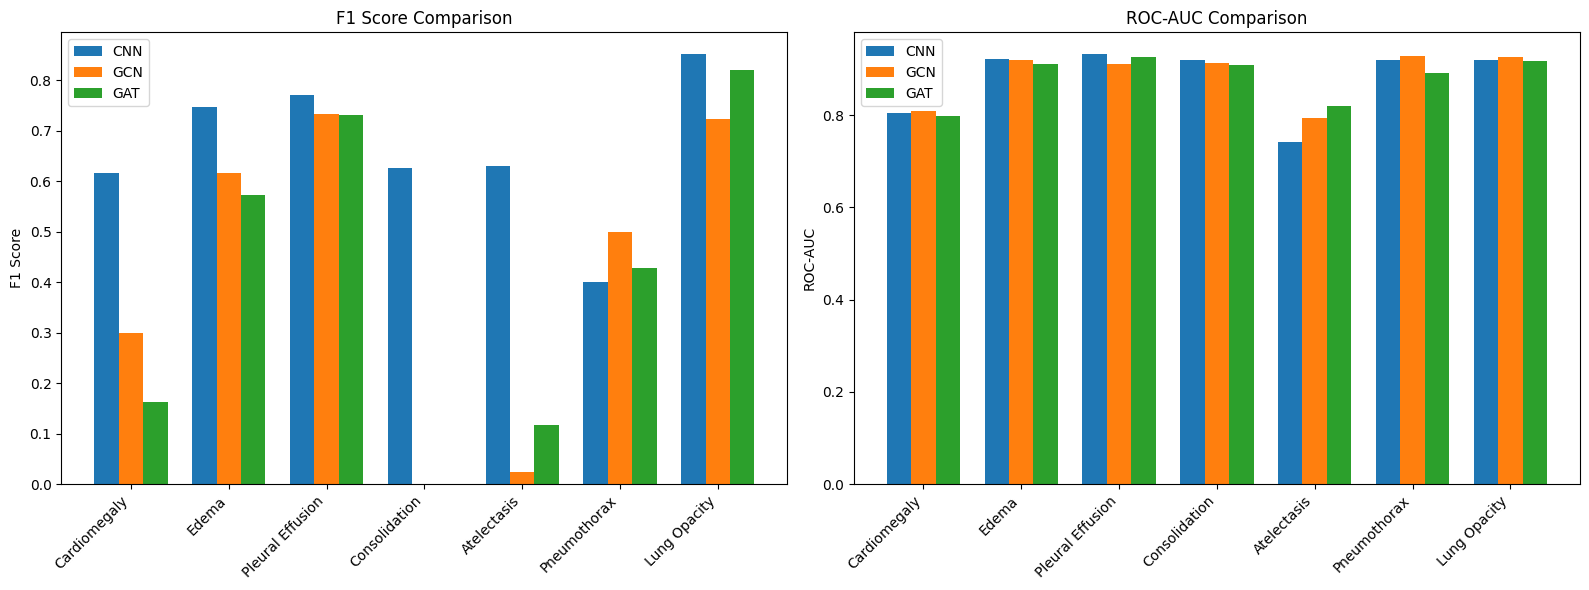

,Disease,CNN_F1,GCN_F1,GAT_F1,CNN_AUC,GCN_AUC,GAT_AUC
0,Cardiomegaly,0.616438,0.300000,0.162162,0.804483,0.809266,0.798104
1,Edema,0.747253,0.615385,0.571429,0.922399,0.918283,0.910641
2,Pleural Effusion,0.770370,0.732394,0.731707,0.932702,0.911610,0.925552
3,Consolidation,0.626506,0.000000,0.000000,0.918740,0.912709,0.908186
4,Atelectasis,0.629108,0.024691,0.117647,0.741315,0.793344,0.818669
5,Pneumothorax,0.400000,0.500000,0.428571,0.920354,0.927544,0.891593
6,Lung Opacity,0.851852,0.722772,0.819383,0.919533,0.925779,0.918210


In [24]:
import numpy as np

x = np.arange(len(DISEASES))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# F1 comparison
axes[0].bar(x - width, [cnn_f1[d] for d in DISEASES], width, label="CNN")
axes[0].bar(x, [gcn_f1[d] for d in DISEASES], width, label="GCN")
axes[0].bar(x + width, [gat_f1[d] for d in DISEASES], width, label="GAT")
axes[0].set_xticks(x)
axes[0].set_xticklabels(DISEASES, rotation=45, ha="right")
axes[0].set_ylabel("F1 Score")
axes[0].set_title("F1 Score Comparison")
axes[0].legend()

# AUC comparison
axes[1].bar(x - width, [cnn_auc[d] for d in DISEASES], width, label="CNN")
axes[1].bar(x, [gcn_auc[d] for d in DISEASES], width, label="GCN")
axes[1].bar(x + width, [gat_auc[d] for d in DISEASES], width, label="GAT")
axes[1].set_xticks(x)
axes[1].set_xticklabels(DISEASES, rotation=45, ha="right")
axes[1].set_ylabel("ROC-AUC")
axes[1].set_title("ROC-AUC Comparison")
axes[1].legend()

plt.tight_layout()
plt.savefig("final_comparison.png")
plt.show()

# Summary table
summary = pd.DataFrame({
    "Disease": DISEASES,
    "CNN_F1": [cnn_f1[d] for d in DISEASES],
    "GCN_F1": [gcn_f1[d] for d in DISEASES],
    "GAT_F1": [gat_f1[d] for d in DISEASES],
    "CNN_AUC": [cnn_auc[d] for d in DISEASES],
    "GCN_AUC": [gcn_auc[d] for d in DISEASES],
    "GAT_AUC": [gat_auc[d] for d in DISEASES],
})
summary.to_csv("final_results.csv", index=False)
summary

In [ ]:
all_features=[]
all_labels=[]

densenet.eval()

with torch.no_grad():

    for images,labels in train_loader:

        images=images.to(device)

        features=densenet(images)

        all_features.append(features.cpu())

        all_labels.append(labels)

all_features=torch.cat(all_features,dim=0)
all_labels=torch.cat(all_labels,dim=0)

print(all_features.shape)
print(all_labels.shape)

In [ ]:
graph_features=[]

for feature in all_features:

    node_feature=torch.stack([
        feature[:341],
        feature[341:682],
        feature[682:1023]
    ])

    graph_features.append(node_feature)

graph_features=torch.stack(graph_features)

print(graph_features.shape)

In [ ]:
from torch.utils.data import Dataset

class GraphDataset(Dataset):

    def __init__(self,features,labels):

        self.features=features
        self.labels=labels

    def __len__(self):

        return len(self.features)

    def __getitem__(self,idx):

        return (
            self.features[idx],
            self.labels[idx]
        )

graph_dataset=GraphDataset(
    graph_features,
    all_labels
)

print(len(graph_dataset))

In [ ]:
from torch.utils.data import DataLoader

graph_loader=DataLoader(
    graph_dataset,
    batch_size=32,
    shuffle=True
)

print(len(graph_loader))

In [ ]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_gcn=model_gcn.to(device)

criterion=nn.BCEWithLogitsLoss()

optimizer=torch.optim.Adam(
    model_gcn.parameters(),
    lr=0.001
)

num_epochs=10

for epoch in range(num_epochs):

    model_gcn.train()

    running_loss=0.0

    for node_features_batch,labels_batch in graph_loader:

        batch_loss=0

        for i in range(node_features_batch.size(0)):

            x=node_features_batch[i].to(device)

            y=labels_batch[i].float().unsqueeze(1).to(device)

            optimizer.zero_grad()

            output=model_gcn(
                x,
                edge_index.to(device)
            )

            loss=criterion(
                output,
                y
            )

            loss.backward()

            optimizer.step()

            batch_loss+=loss.item()

        running_loss+=batch_loss

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {running_loss/len(graph_dataset):.4f}"
    )

In [ ]:
val_features=[]
val_labels=[]

densenet.eval()

with torch.no_grad():

    for images,labels in val_loader:

        images=images.to(device)

        features=densenet(images)

        val_features.append(features.cpu())

        val_labels.append(labels)

val_features=torch.cat(val_features,dim=0)
val_labels=torch.cat(val_labels,dim=0)

print(val_features.shape)
print(val_labels.shape)

In [ ]:
val_graph_features=[]

for feature in val_features:

    node_feature=torch.stack([
        feature[:341],
        feature[341:682],
        feature[682:1023]
    ])

    val_graph_features.append(node_feature)

val_graph_features=torch.stack(val_graph_features)

print(val_graph_features.shape)

In [ ]:
model_gcn.eval()

all_preds=[]
all_targets=[]

with torch.no_grad():

    for i in range(len(val_graph_features)):

        x=val_graph_features[i].to(device)

        output=model_gcn(
            x,
            edge_index.to(device)
        )

        probs=torch.sigmoid(output)

        all_preds.append(
            probs.cpu().numpy().flatten()
        )

        all_targets.append(
            val_labels[i].numpy()
        )

all_preds=np.array(all_preds)
all_targets=np.array(all_targets)

print(all_preds.shape)
print(all_targets.shape)

In [ ]:
from sklearn.metrics import f1_score

pred_binary=(all_preds>0.5).astype(int)

disease_names=[
    "Cardiomegaly",
    "Edema",
    "Pleural Effusion"
]

for i,disease in enumerate(disease_names):

    f1=f1_score(
        all_targets[:,i],
        pred_binary[:,i]
    )

    print(
        disease,
        "F1 Score:",
        f1
    )

In [ ]:
from sklearn.metrics import roc_auc_score

for i,disease in enumerate(disease_names):

    auc=roc_auc_score(
        all_targets[:,i],
        all_preds[:,i]
    )

    print(
        disease,
        "ROC-AUC:",
        auc
    )

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

comparison=pd.DataFrame({
    "Disease":["Cardiomegaly","Edema","Pleural Effusion"],
    "CNN":[0.5573,0.7432,0.7733],
    "GNN":[0.5390,0.7005,0.7220]
})

comparison.plot(
    x="Disease",
    y=["CNN","GNN"],
    kind="bar",
    figsize=(8,5)
)

plt.ylabel("F1 Score")
plt.title("CNN vs GNN F1 Score Comparison")
plt.grid(axis="y")
plt.show()

In [ ]:
comparison=pd.DataFrame({
    "Disease":["Cardiomegaly","Edema","Pleural Effusion"],
    "CNN":[0.7299,0.7072,0.7423],
    "GNN":[0.4903,0.6242,0.6204]
})

comparison.plot(
    x="Disease",
    y=["CNN","GNN"],
    kind="bar",
    figsize=(8,5)
)

plt.ylabel("ROC-AUC")
plt.title("CNN vs GNN ROC-AUC Comparison")
plt.grid(axis="y")
plt.show()